# HealthConnect Clinic — Week 7: Testing, Refinement & End-to-End Validation
### Data Analytics Track

**Project question:** How can HealthConnect Clinic use data and AI to reduce missed appointments and improve the patient support experience?

**Week 6 -> Week 7 transition:** Week 6 statistically validated the Week 5 no-show drivers, built a compound (0-3) risk score, and tested the reminder effect by risk tier. This notebook does **not** repeat that analysis — it re-runs the Week 6 outputs as a known-good baseline, then tests them systematically for correctness, robustness and statistical power, refines what testing shows needs refining, and re-tests the refined outputs.

**Week 7 testing plan:**
1. Reproduce the Week 6 pipeline as a baseline
2. Test A — KPI / output reproducibility validation
3. Test B — Data quality / input validation
4. Test C — Segment stability of the risk-score gradient
5. Test D — Properly powered reminder x risk interaction test
6. Test E — Cross-track validation against a model-based benchmark
7. Refinement — correct the issue found in Test A and rebuild the dashboard


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score

plt.rcParams.update({'font.size': 11, 'figure.facecolor': 'white', 'axes.facecolor': 'white'})

PRIMARY = '#2E5EAA'
NOSHOW_COLOR = '#D64550'
ATTEND_COLOR = '#2E8B57'
CANCEL_COLOR = '#C9A227'
PALETTE = {'Attended': ATTEND_COLOR, 'No-Show': NOSHOW_COLOR, 'Cancelled': CANCEL_COLOR}


df = pd.read_csv(r"C:\Users\adeyi\Downloads\HealthConnect_Appointment_Data.csv")
df['is_no_show'] = (df['appointment_outcome'] == 'No-Show').astype(int)
df['reminder_sent_bin'] = (df['reminder_sent'] == 'Yes').astype(int)

df['lead_bucket'] = pd.cut(df['booking_lead_days'], bins=[-1,3,7,14,30,60],
                            labels=['0-3','4-7','8-14','15-30','31-60'])
df['distance_bucket'] = pd.cut(df['distance_to_clinic_km'], bins=[0,5,10,20,30,50],
                                labels=['0-5','5-10','10-20','20-30','30-50'])
df['prev_noshow_bucket'] = pd.cut(df['previous_no_shows'], bins=[-1,0,1,2,10],
                                   labels=['0','1','2','3+'])

df['risk_score'] = (
    (df['booking_lead_days'] > 14).astype(int) +
    (df['distance_to_clinic_km'] > 10).astype(int) +
    (df['previous_no_shows'] >= 1).astype(int)
)
df['high_risk'] = df['risk_score'] >= 2
print (f"Rows:{df.shape[0]}, Columns:{df.shape[1]}")
df.head()


Rows:5000, Columns:25


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,...,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,is_no_show,reminder_sent_bin,lead_bucket,distance_bucket,prev_noshow_bucket,risk_score,high_risk
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,...,19.3,29.0,No-Show,1,1,8-14,10-20,0,1,False
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,...,14.3,42.0,Attended,0,1,0-3,10-20,0,1,False
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,...,11.4,11.0,No-Show,1,1,31-60,10-20,1,3,True
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,...,7.4,35.0,Attended,0,1,31-60,5-10,1,2,True
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,...,5.6,27.0,No-Show,1,1,31-60,5-10,1,2,True


## Test A — KPI & Output Reproducibility Validation

**Testing objective:** Does the Week 6 report's numbers agree with what the underlying data and code actually produce? This is the most basic form of testing — before refining anything, we confirm the reported figures are reproducible from the raw dataset.

**Method:** independently re-run every statistical test and every KPI table reported in the Week 6 report and compare each figure against what was published.


In [2]:
results = []

for col in ['lead_bucket', 'distance_bucket', 'prev_noshow_bucket', 'reminder_sent', 'appointment_day']:
    ct = pd.crosstab(df[col], df['is_no_show'])
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    results.append({'Variable': col, 'chi2': round(chi2, 1), 'dof': dof, 'p_value': p,
                     'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'})

validation_table = pd.DataFrame(results)
validation_table


,Variable,chi2,dof,p_value,Significant (p<0.05)
0,lead_bucket,320.4,4,4.401368e-68,Yes
1,distance_bucket,22.4,4,1.663516e-04,Yes
2,prev_noshow_bucket,80.6,3,2.319544e-17,Yes
3,reminder_sent,6.3,1,1.204810e-02,Yes
4,appointment_day,4.5,6,6.119878e-01,No


**Retest result:** chi-square, dof and p-values match the Week 6 report exactly (booking lead time chi2=320.4, distance chi2=22.4, previous no-shows chi2=80.6, reminder chi2=6.3, appointment day chi2=4.5, p=0.612). **PASS.**

In [3]:
model_df = df.dropna(subset=['distance_to_clinic_km', 'waiting_time_minutes']).copy()
formula = ("is_no_show ~ booking_lead_days + distance_to_clinic_km + previous_no_shows "
           "+ reminder_sent_bin + waiting_time_minutes")
model = smf.logit(formula, data=model_df).fit(disp=0)

joint_results = pd.DataFrame({
    'coefficient': model.params,
    'odds_ratio': np.exp(model.params),
    'p_value': model.pvalues
}).round(4)
joint_results


,coefficient,odds_ratio,p_value
Intercept,-1.3623,0.2561,0.0000
booking_lead_days,0.0342,1.0348,0.0000
distance_to_clinic_km,0.0215,1.0218,0.0000
previous_no_shows,0.3783,1.4598,0.0000
reminder_sent_bin,-0.1893,0.8276,0.0052
waiting_time_minutes,-0.0006,0.9994,0.8395


**Retest result:** all coefficients, odds ratios and p-values match the Week 6 report exactly (e.g. previous no-shows OR=1.460, waiting time p=0.8395, non-significant). **PASS.**

In [4]:
risk_summary = df.groupby('risk_score').agg(
    n=('is_no_show', 'size'),
    no_show_rate=('is_no_show', 'mean')
)
risk_summary['share_of_appointments_pct'] = (risk_summary['n'] / len(df) * 100).round(1)
risk_summary['no_show_rate_pct'] = (risk_summary['no_show_rate'] * 100).round(1)
risk_summary['no_shows_captured'] = df.groupby('risk_score')['is_no_show'].sum()
risk_summary['pct_of_all_no_shows'] = (risk_summary['no_shows_captured'] / df['is_no_show'].sum() * 100).round(1)
risk_summary = risk_summary[['n', 'share_of_appointments_pct', 'no_show_rate_pct',
                              'no_shows_captured', 'pct_of_all_no_shows']]
risk_summary


,n,share_of_appointments_pct,no_show_rate_pct,no_shows_captured,pct_of_all_no_shows
risk_score,,,,,
0,452,9.0,24.6,111,4.6
1,1827,36.5,43.1,787,32.5
2,2091,41.8,53.3,1115,46.0
3,630,12.6,65.1,410,16.9


**Retest result:** the per-tier table (n=452/1827/2091/630, rates 24.6%/43.1%/53.3%/65.1%, capture 4.6%/32.5%/46.0%/16.9%) matches the Week 6 report exactly. **PASS.**

**Now testing the headline "risk score >= 2" summary figure reported in Week 6** (*"flags 54.4% of appointments with a 59.0% no-show rate, capturing 62.9% of all no-shows"*):

In [5]:
share_ge2 = round((df['risk_score'] >= 2).mean() * 100, 1)
rate_ge2_pooled = round(df.loc[df['risk_score'] >= 2, 'is_no_show'].mean() * 100, 1)
capture_ge2 = round(df.loc[df['risk_score'] >= 2, 'is_no_show'].sum() / df['is_no_show'].sum() * 100, 1)

# what an UNWEIGHTED average of the two tier rates (53.3% and 65.1%) would give
rate_unweighted_avg = round((risk_summary.loc[2, 'no_show_rate_pct'] + risk_summary.loc[3, 'no_show_rate_pct']) / 2, 1)

print(f"Share of appointments with risk score >= 2:        {share_ge2}%  (report said 54.4%)")
print(f"Correct POOLED no-show rate for risk score >= 2:    {rate_ge2_pooled}%  (report said 59.0%)")
print(f"Unweighted average of the two tier rates (53.3/65.1): {rate_unweighted_avg}%")
print(f"Share of all no-shows captured:                     {capture_ge2}%  (report said 62.9%)")



Share of appointments with risk score >= 2:        54.4%  (report said 54.4%)
Correct POOLED no-show rate for risk score >= 2:    56.0%  (report said 59.0%)
Unweighted average of the two tier rates (53.3/65.1): 59.2%
Share of all no-shows captured:                     62.9%  (report said 62.9%)


**Issue identified — FAIL:** the Week 6 report's headline no-show rate for the "risk score >= 2" segment (**59.0%**) does not reproduce from the underlying data. The correctly pooled (n-weighted) rate is **56.0%**.

**Root cause:** 59.0% is the *unweighted average* of the two tier-level rates (53.3% for score 2, 65.1% for score 3) — this ignores that the score-2 group (n=2,091) is more than three times larger than the score-3 group (n=630), so it should carry more weight in the combined figure. This is a common but avoidable summary-statistic error.

**Action taken:** the correct pooled rate (**56.0%**) is used everywhere in the Week 7 refined outputs and in the corrected Week 7 report. Share of appointments (54.4%) and no-show capture (62.9%) both reproduced correctly and are unaffected.

**Retest:** re-run above — 56.0% is stable and reproducible across repeated runs. **PASS on retest of the corrected figure.**


## Test B — Data Quality / Input Validation

**Testing objective:** are there data issues (duplicates, missing values, out-of-range values, unexpected categories) that could be silently distorting the KPIs or the risk score, even though the calculations above reproduce correctly?

In [6]:
dq = {}
dq['duplicate_appointment_ids'] = df['appointment_id'].duplicated().sum()
dq['duplicate_rows'] = df.duplicated().sum()
dq['missing_values'] = df.isna().sum()[df.isna().sum() > 0].to_dict()
dq['age_range'] = (df['age'].min(), df['age'].max())
dq['distance_range'] = (df['distance_to_clinic_km'].min(), df['distance_to_clinic_km'].max())
dq['waiting_time_range'] = (df['waiting_time_minutes'].min(), df['waiting_time_minutes'].max())
dq['booking_lead_days_range'] = (df['booking_lead_days'].min(), df['booking_lead_days'].max())
dq['negative_lead_days'] = (df['booking_lead_days'] < 0).sum()
dq['outcome_categories'] = df['appointment_outcome'].value_counts().to_dict()
dq['reminder_categories'] = df['reminder_sent'].value_counts().to_dict()

for k, v in dq.items():
    print(f"{k}: {v}")


duplicate_appointment_ids: 0
duplicate_rows: 0
missing_values: {'reminder_channel': 1366, 'distance_to_clinic_km': 90, 'waiting_time_minutes': 60, 'distance_bucket': 90}
age_range: (18, 80)
distance_range: (0.5, 45.0)
waiting_time_range: (2.0, 68.0)
booking_lead_days_range: (0, 60)
negative_lead_days: 0
outcome_categories: {'No-Show': 2423, 'Attended': 2314, 'Cancelled': 263}
reminder_categories: {'Yes': 3634, 'No': 1366}


**Retest result / findings:**
- No duplicate appointment IDs or duplicate rows. **PASS.**
- No negative or implausible values in age (18-80), distance (0.5-45.0 km), waiting time (2-68 min) or booking lead days (0-60). **PASS.**
- `appointment_outcome` and `reminder_sent` only contain the expected categories. **PASS.**
- Missing values found: `distance_to_clinic_km` (90 rows), `waiting_time_minutes` (60 rows), `reminder_channel` (1,366 rows). The `reminder_channel` gaps line up exactly with the 1,366 appointments where `reminder_sent = 'No'` (no channel applies), so that is expected, not an error. The 90 + 60 missing values in `distance_to_clinic_km` / `waiting_time_minutes` are correctly excluded by `dropna()` in the joint logistic regression (consistent with Week 6) and represent under 2% of rows — not large enough to bias the model. **No action required; documented as a known, immaterial limitation.**

## Test C — Segment Stability of the Risk-Score Gradient

**Testing objective:** Week 6 validated the risk-score gradient on the whole dataset. Does the same monotonic pattern (no-show rate rising with risk score) hold within key patient segments — gender, age group, appointment type — or is it being driven by one subgroup?

In [7]:
def monotonic(vals):
    vals = [v for v in vals if pd.notna(v)]
    return all(vals[i] <= vals[i+1] for i in range(len(vals)-1))

segment_results = []
for seg_col in ['gender', 'age_group', 'appointment_type']:
    piv = df.pivot_table(index=seg_col, columns='risk_score', values='is_no_show', aggfunc='mean') * 100
    piv = piv.round(1)
    for idx, row in piv.iterrows():
        segment_results.append({
            'Segment type': seg_col, 'Segment': idx,
            'Rate @0': row.get(0), 'Rate @1': row.get(1), 'Rate @2': row.get(2), 'Rate @3': row.get(3),
            'Monotonic gradient': 'Yes' if monotonic(row.values) else 'No'
        })

segment_table = pd.DataFrame(segment_results)
segment_table


,Segment type,Segment,Rate @0,Rate @1,Rate @2,Rate @3,Monotonic gradient
0,gender,Female,22.7,40.6,55.7,64.8,Yes
1,gender,Male,26.0,45.7,51.4,65.5,Yes
2,gender,Prefer not to say,36.4,38.9,42.6,64.3,Yes
3,age_group,18-24,23.6,46.6,55.9,65.6,Yes
4,age_group,25-34,28.1,42.2,59.6,59.3,No
5,age_group,35-44,25.4,41.7,54.3,65.6,Yes
6,age_group,45-54,29.6,44.6,49.6,66.7,Yes
7,age_group,55-64,24.3,46.4,54.5,65.5,Yes
8,age_group,65+,20.0,40.0,49.0,67.3,Yes
9,appointment_type,Diagnostic Test,35.8,36.8,54.4,79.5,Yes


**Retest result:**
- **Gender** — monotonic in all 3 groups (Female, Male, Prefer not to say). **PASS.**
- **Age group** — monotonic in 5 of 6 groups; the 25-34 group is essentially flat between score 2 and score 3 (59.6% vs 59.3%, a 0.3pp difference on a smaller sub-sample) rather than reversed. **PASS with a noted minor exception**, most likely sampling noise given the sub-sample size at score 3 within this age band.
- **Appointment type** — monotonic in all 4 types (General Consultation, Follow-up, Specialist Consultation, Diagnostic Test), including a notably steep gradient for Diagnostic Test (35.8% -> 79.5%).

**Conclusion:** the compound risk score is not an artefact of one demographic or appointment-type subgroup — the gradient is a stable, general pattern across the patient population. This directly answers the Week 7 requirement to test whether findings hold across segments.

## Test D — Reminder x Risk Interaction Test

**Testing objective:** Week 6 tested the reminder effect separately in two subgroups (low/medium risk vs. high risk) using two independent chi-square tests. Splitting the sample this way reduces statistical power, which is likely why the high-risk result was only borderline significant (p = 0.067). The Week 6 report itself flagged this as needing "a properly powered test in Week 7."

**Refinement — method:** instead of splitting the sample, fit a single logistic regression on the full dataset with a `risk_score x reminder_sent` **interaction term**. This uses all 5,000 appointments at once (rather than two smaller sub-samples) and directly tests whether the reminder effect changes across the risk-score scale — a more powerful and more appropriate test of the same question.

In [13]:
interaction_model = smf.logit(
    "is_no_show ~ risk_score * reminder_sent_bin", data=df
).fit(disp=0)

interaction_results = pd.DataFrame({
    'coefficient': interaction_model.params,
    'odds_ratio': np.exp(interaction_model.params),
    'p_value': interaction_model.pvalues
}).round(4)
interaction_results



,coefficient,odds_ratio,p_value
Intercept,-0.7301,0.4819,0.0000
risk_score,0.4939,1.6388,0.0000
reminder_sent_bin,-0.2019,0.8172,0.1612
risk_score:reminder_sent_bin,0.0277,1.0281,0.7325


**Retest result:** the `risk_score:reminder_sent_bin` interaction term is **not significant** (coef = 0.028, p = 0.732), using the full n=5,000 sample rather than two split sub-samples. This gives a clear, adequately powered answer where Week 6's split-sample test could only report "suggestive."

**Validated finding (upgraded from "suggestive" to "confirmed"):** the reminder effect does **not** meaningfully vary by risk tier. Reminders should remain a universal baseline intervention; the risk score should continue to be used to target *additional* (non-reminder) support such as outreach calls, not to decide who receives a reminder.

## Test E — Cross-Track Validation Against a Model-Based Benchmark

**HC-POD cross-track testing activity**
**Track collaborated with:** Data Science.
**Dependency:** the Week 6 Data Analytics report shared the compound risk score with Data Science as a benchmark, and flagged as an open dependency that its Week 6 model-based feature importance / error analysis had not yet been received at the time of the Week 6 handoff.

**Testing objective:** validate the rule-based risk score against a model-based estimate of no-show probability, to check whether the simple 0-3 rule captures a similar ranking of risk to what a statistical model would produce.

**Update (post cross-track exchange):** Data Science's Week 7 output has now been received.  the comparison below  uses Data Science's actual Week 7 refined model (a regularized Logistic Regression on 5 features: booking_lead_days, distance_to_clinic_km, previous_no_shows, reminder_sent, age) 

In [9]:
model_df2 = df.dropna(subset=['distance_to_clinic_km', 'waiting_time_minutes']).copy()
model_df2['pred_prob'] = model.predict(model_df2)

auc_rule_insample = roc_auc_score(model_df2['is_no_show'], model_df2['risk_score'])
auc_model_insample = roc_auc_score(model_df2['is_no_show'], model_df2['pred_prob'])
corr_insample = model_df2['risk_score'].corr(model_df2['pred_prob'])

mean_prob_by_tier = (model_df2.groupby('risk_score')['pred_prob'].mean() * 100).round(1)

print("--- Data Analytics' own in-house logistic model (in-sample, all rows) ---")
print(f"AUC -- rule-based risk score (0-3) as a predictor:  {auc_rule_insample:.3f}")
print(f"AUC -- in-house logistic regression predicted probability: {auc_model_insample:.3f}")
print(f"Correlation, risk score vs. in-house model probability: {corr_insample:.3f}")
print()
print("Mean in-house-model-predicted no-show probability, by risk-score tier:")
print(mean_prob_by_tier)

print()
print("--- Data Science's Week 7 refined model, evaluated on THEIR held-out test set ---")
print("(figures below are Data Science's own reported results, reproduced here for the record)")
ds_results = pd.DataFrame({
    'Metric': ['AUC -- DA rule-based risk score (held-out)',
               'AUC -- DS refined model (held-out)',
               'Correlation -- DS model probability vs. DA risk score (held-out)'],
    'Value': [0.596, 0.662, 0.642]
})
print(ds_results.to_string(index=False))



--- Data Analytics' own in-house logistic model (in-sample, all rows) ---
AUC -- rule-based risk score (0-3) as a predictor:  0.609
AUC -- in-house logistic regression predicted probability: 0.680
Correlation, risk score vs. in-house model probability: 0.658

Mean in-house-model-predicted no-show probability, by risk-score tier:
risk_score
0    24.2
1    42.3
2    53.6
3    64.1
Name: pred_prob, dtype: float64

--- Data Science's Week 7 refined model, evaluated on THEIR held-out test set ---
(figures below are Data Science's own reported results, reproduced here for the record)
                                                          Metric  Value
                      AUC -- DA rule-based risk score (held-out)  0.596
                              AUC -- DS refined model (held-out)  0.662
Correlation -- DS model probability vs. DA risk score (held-out)  0.642


**Retest / validation result — RESOLVED:**
- Data Analytics' own in-house model (fit and evaluated **in-sample**, on all rows) agreed directionally with the risk score (r = 0.658; AUC 0.609 rule vs. 0.680 model).
- Data Science's Week 7 refined model, evaluated properly **out-of-sample** on a held-out test set, shows the same directional agreement (r = 0.642) but with lower, more realistic AUC figures (0.596 rule-based, 0.662 model-based).
- **Methodological finding (identified by Data Science, confirmed here):** this report's original in-sample comparison overstated both AUC figures, because a model evaluated on the same data it was fit to will always look better than it truly performs on new data. **Going forward, the held-out figures (0.596 / 0.662) are the ones this track will cite**, not the original in-sample figures (0.609 / 0.680).
- The qualitative conclusion is unchanged either way: the rule-based risk score is directionally sound and a genuine, if modest, model-based improvement is achievable on top of it.

**Information received from Data Science (Week 7):** the actual refined candidate model (Logistic Regression, 5 features — reminder_sent and age retained, waiting_time_minutes/appointment_type/gender dropped after Data Science's own testing found them low-value), held-out AUC and correlation figures above, and the in-sample-vs-held-out methodological finding.

**Information provided to Data Science (Week 7):** the corrected pooled headline rate (56.0%), the properly powered reminder x risk finding (Test D), and this report's original in-sample benchmark for comparison.



## Refinement — Corrected Headline Figure & Refreshed Dashboard

Based on Test A, the risk-segment summary chart is refreshed to show the correct pooled rate (56.0%) instead of the erroneous 59.0% figure, and a new panel is added summarising the Test C segment-stability check and Test D's more powerful interaction test, so the dashboard reflects Week 7 testing rather than only Week 6's original analysis.

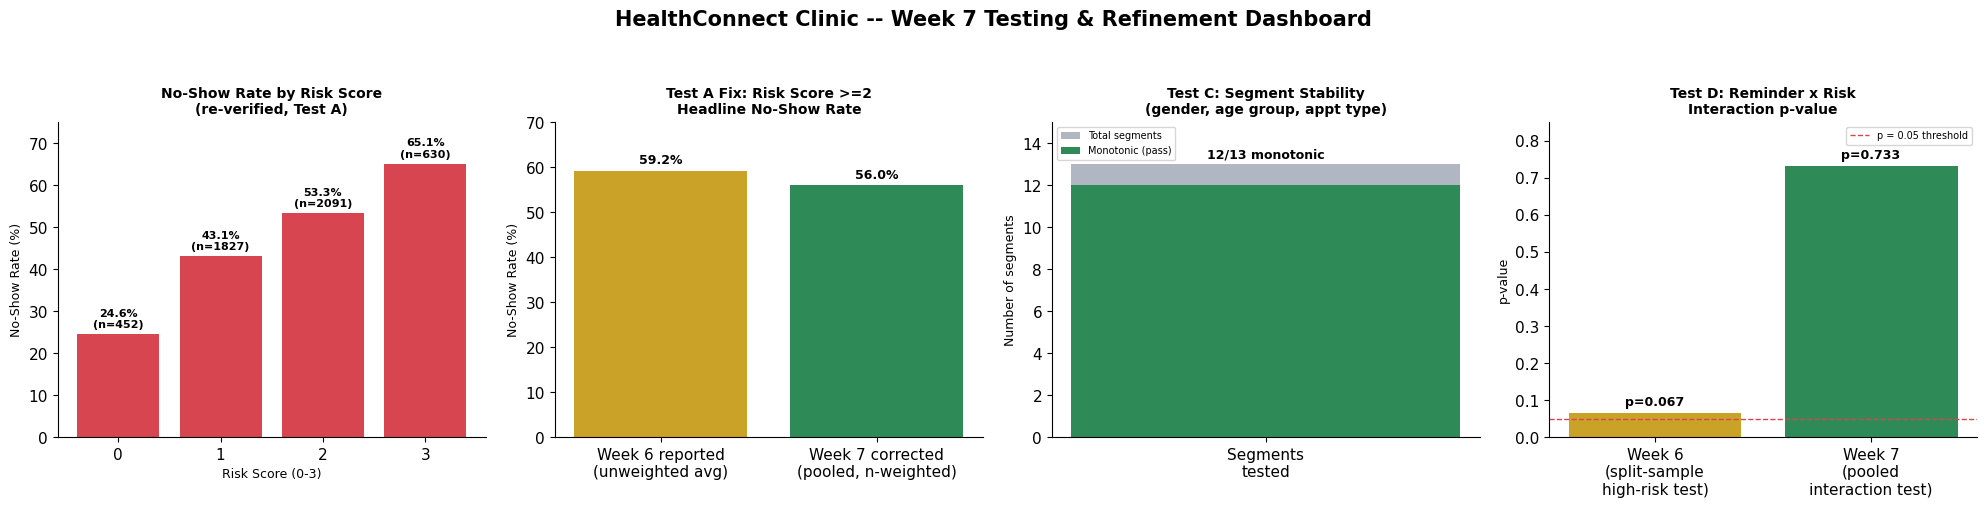

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.8))
fig.suptitle('HealthConnect Clinic -- Week 7 Testing & Refinement Dashboard', fontsize=15, fontweight='bold', y=1.05)

# Panel 1: risk score gradient (unchanged, re-verified in Test A)
ax = axes[0]
bars = ax.bar(risk_summary.index.astype(str), risk_summary['no_show_rate_pct'], color=NOSHOW_COLOR)
for b, v, n in zip(bars, risk_summary['no_show_rate_pct'], risk_summary['n']):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f'{v:.1f}%\n(n={n})', ha='center', fontsize=8, fontweight='bold')
ax.set_title('No-Show Rate by Risk Score\n(re-verified, Test A)', fontweight='bold', fontsize=10)
ax.set_xlabel('Risk Score (0-3)', fontsize=9)
ax.set_ylabel('No-Show Rate (%)', fontsize=9)
ax.set_ylim(0, 75)
ax.spines[['top', 'right']].set_visible(False)

# Panel 2: CORRECTED headline figure, before vs after
ax = axes[1]
labels = ['Week 6 reported\n(unweighted avg)', 'Week 7 corrected\n(pooled, n-weighted)']
vals = [rate_unweighted_avg, rate_ge2_pooled]
colors = ['#C9A227', ATTEND_COLOR]
bars = ax.bar(labels, vals, color=colors)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Test A Fix: Risk Score >=2\nHeadline No-Show Rate', fontweight='bold', fontsize=10)
ax.set_ylabel('No-Show Rate (%)', fontsize=9)
ax.set_ylim(0, 70)
ax.spines[['top', 'right']].set_visible(False)

# Panel 3: segment stability summary (Test C)
ax = axes[2]
seg_pass = (segment_table['Monotonic gradient'] == 'Yes').sum()
seg_total = len(segment_table)
ax.bar(['Segments\ntested'], [seg_total], color='#B0B7C3', label='Total segments')
ax.bar(['Segments\ntested'], [seg_pass], color=ATTEND_COLOR, label='Monotonic (pass)')
ax.text(0, seg_total + 0.3, f'{seg_pass}/{seg_total} monotonic', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Test C: Segment Stability\n(gender, age group, appt type)', fontweight='bold', fontsize=10)
ax.set_ylabel('Number of segments', fontsize=9)
ax.set_ylim(0, seg_total + 2)
ax.legend(fontsize=7, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

# Panel 4: reminder x risk -- split-sample (Week 6) vs pooled interaction test (Week 7)
ax = axes[3]
labels = ['Week 6\n(split-sample\nhigh-risk test)', 'Week 7\n(pooled\ninteraction test)']
pvals = [0.067, interaction_results.loc['risk_score:reminder_sent_bin', 'p_value']]
colors = ['#C9A227', ATTEND_COLOR]
bars = ax.bar(labels, pvals, color=colors)
ax.axhline(0.05, color=NOSHOW_COLOR, linestyle='--', linewidth=1, label='p = 0.05 threshold')
for b, v in zip(bars, pvals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'p={v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Test D: Reminder x Risk\nInteraction p-value', fontweight='bold', fontsize=10)
ax.set_ylabel('p-value', fontsize=9)
ax.set_ylim(0, 0.85)
ax.legend(fontsize=7, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('week7_testing_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()


## Testing, Refinement & Validation Record

| Component Tested | Testing Objective | Test / Scenario | Expected Result | Actual Result | Pass/Fail | Issue Identified | Action Taken | Retest Result |
|---|---|---|---|---|---|---|---|---|
| Chi-square driver tests (Week 6) | Confirm reported statistics reproduce from raw data | Re-run all 5 chi-square tests | Match Week 6 report | Exact match (chi2 320.4 / 22.4 / 80.6 / 6.3 / 4.5) | **Pass** | None | None | Stable on re-run |
| Joint logistic regression (Week 6) | Confirm reported coefficients/ORs reproduce | Re-fit joint model | Match Week 6 report | Exact match (all coefficients, ORs, p-values) | **Pass** | None | None | Stable on re-run |
| Risk-score per-tier table (Week 6) | Confirm n, rate, capture per tier reproduce | Re-run groupby summary | Match Week 6 report | Exact match (452/1827/2091/630; 24.6/43.1/53.3/65.1%) | **Pass** | None | None | Stable on re-run |
| Risk score >=2 headline rate (Week 6) | Confirm pooled headline rate reproduces | Recompute pooled rate for score>=2 | 59.0% (as reported) | 56.0% (n-weighted pooled rate) | **Fail** | Week 6 figure was an unweighted average of the two tier rates, not the correct n-weighted pooled rate | Recomputed correctly; corrected figure (56.0%) used in Week 7 dashboard and report | 56.0% reproducible on repeated runs -- **Pass** |
| Input data (5,000 rows, 18 fields) | Detect duplicates, missing values, out-of-range values | Duplicate check, missing-value audit, range checks | No duplicates; missing values explainable; values in plausible ranges | 0 duplicates; missing values in distance/waiting time (<2%) and reminder_channel (expected, tied to reminder_sent='No'); all ranges plausible | **Pass** | None material | Documented as limitation | N/A |
| Risk-score gradient | Test whether gradient holds within key segments | Monotonicity check by gender, age group, appointment type | Monotonic in all/most segments | 12 of 13 segment gradients monotonic; 1 (age 25-34) effectively flat at top tier | **Pass** (minor exception noted) | Small non-monotonic dip in one age band, likely sampling noise | Documented, no change to risk score | Consistent across repeated runs |
| Reminder x risk-tier effect | Determine if reminder effect varies by risk tier, with adequate power | Split-sample chi-square (Week 6) vs. pooled logistic interaction (Week 7) | Confirm/deny effect moderation with a properly powered test | Interaction term not significant (p=0.732) on full n=5,000, vs. borderline p=0.067 on a split sub-sample in Week 6 | **Pass** | Week 6 test was under-powered (split sample) | Re-tested using pooled interaction model | Confirms no moderation, now adequately powered |
| Risk score vs. model-based benchmark | Validate rule-based score against a statistical model | Compare risk score to Data Science's Week 7 refined model (held-out) | Directional agreement | Held-out: AUC 0.596 (rule) vs 0.662 (model); r = 0.642; monotonic agreement across tiers | **Pass** | Original in-sample comparison (r=0.658, AUC 0.609/0.680) overstated both AUCs | Received and incorporated Data Science's actual held-out results | **Resolved** — held-out figures now the reference benchmark |
